# Football Match Prediction & Betting Market Analysis

Author: Charlie Findley

## Project Goal

The aim of this project is to build machine learning models that predict
Premier League match outcomes and compare those predictions against
bookmaker odds to investigate market efficiency and potential betting value.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

## Dataset

The dataset contains match statistics, results, and bookmaker odds from
the English Premier League 2024-25 season.

In [4]:
df = pd.read_csv("historical_football_data.csv")
df.head()

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,BFECAHH,BFECAHA
0,E0,16/08/2024,20:00,Man United,Fulham,1,0,H,0,0,...,1.86,2.07,1.83,2.11,1.88,2.11,1.82,2.05,1.90,2.08
1,E0,17/08/2024,12:30,Ipswich,Liverpool,0,2,A,0,0,...,2.05,1.88,2.04,1.90,2.20,2.00,1.99,1.88,2.04,1.93
2,E0,17/08/2024,15:00,Arsenal,Wolves,2,0,H,1,0,...,2.02,1.91,2.00,1.90,2.05,1.93,1.99,1.87,2.02,1.96
3,E0,17/08/2024,15:00,Everton,Brighton,0,3,A,0,1,...,1.87,2.06,1.86,2.07,1.92,2.10,1.83,2.04,1.88,2.11
4,E0,17/08/2024,15:00,Newcastle,Southampton,1,0,H,1,0,...,1.87,2.06,1.88,2.06,1.89,2.10,1.82,2.05,1.89,2.10


In [5]:
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 380 entries, 0 to 379
Columns: 120 entries, Div to BFECAHA
dtypes: float64(96), int64(16), str(8)
memory usage: 356.4 KB


,FTHG,FTAG,HTHG,HTAG,HS,AS,HST,AST,HF,AF,...,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,BFECAHH,BFECAHA
count,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,...,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000
mean,1.513158,1.421053,0.752632,0.610526,13.752632,12.165789,4.834211,4.265789,10.789474,11.276316,...,1.946421,1.964842,1.954632,1.971605,1.987842,2.003026,1.925105,1.939237,1.983079,2.006079
std,1.277917,1.189922,0.875867,0.828831,5.588045,5.409987,2.488260,2.341636,3.639840,3.513257,...,0.086484,0.085585,0.084978,0.086511,0.087387,0.087857,0.080514,0.080919,0.088226,0.089331
min,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000,0.000000,0.000000,2.000000,1.000000,...,1.680000,1.730000,1.710000,1.770000,1.830000,1.800000,1.730000,1.750000,1.750000,1.810000
25%,1.000000,1.000000,0.000000,0.000000,10.000000,9.000000,3.000000,3.000000,8.000000,9.000000,...,1.880000,1.907500,1.880000,1.900000,1.910000,1.940000,1.857500,1.870000,1.910000,1.930000
50%,1.000000,1.000000,1.000000,0.000000,13.000000,11.500000,5.000000,4.000000,11.000000,11.000000,...,1.950000,1.970000,1.950000,1.970000,1.990000,2.000000,1.920000,1.940000,1.980000,2.010000
75%,2.000000,2.000000,1.000000,1.000000,17.000000,15.000000,6.000000,6.000000,13.000000,14.000000,...,2.020000,2.040000,2.020000,2.040000,2.050000,2.072500,1.990000,2.010000,2.052500,2.070000
max,7.000000,6.000000,4.000000,5.000000,36.000000,37.000000,16.000000,13.000000,21.000000,21.000000,...,2.100000,2.150000,2.170000,2.260000,2.340000,2.310000,2.130000,2.140000,2.210000,2.300000


# 4. Understanding the Variables

Before any modelling can be performed, it is important to understand the meaning of each variable contained within the dataset. The dataset contains information relating to match outcomes, team performance statistics, and bookmaker odds for Premier League fixtures during the 2024–25 season.

The variables can be grouped into several categories:

---

## 4.1 Match Information

| Variable | Description |
|-----------|------------|
| Div | League division identifier |
| Date | Date on which the match was played |
| Time | Kick-off time |
| HomeTeam | Home team |
| AwayTeam | Away team |

These variables identify the fixture itself and provide contextual information about when and where the match occurred.

---

## 4.2 Match Outcome Variables

| Variable | Description |
|-----------|------------|
| FTHG | Full-Time Home Goals |
| FTAG | Full-Time Away Goals |
| FTR | Full-Time Result (H = Home Win, D = Draw, A = Away Win) |
| HTHG | Half-Time Home Goals |
| HTAG | Half-Time Away Goals |
| HTR | Half-Time Result |

These variables describe the final outcome of the match and are often used as target variables for predictive modelling.

### Target Variable

For this project, the primary target variable is:

**FTR (Full-Time Result)**

where:

- H = Home Win
- D = Draw
- A = Away Win

The objective of the machine learning model will be to predict this result before a match takes place.

---

## 4.3 Shooting Statistics

| Variable | Description |
|-----------|------------|
| HS | Home Team Shots |
| AS | Away Team Shots |
| HST | Home Team Shots on Target |
| AST | Away Team Shots on Target |

These variables measure attacking performance and provide an indication of how threatening each team was during the match.

Generally, teams producing more shots and more shots on target are expected to have a higher probability of winning.

---

## 4.4 Discipline Statistics

| Variable | Description |
|-----------|------------|
| HF | Home Team Fouls Committed |
| AF | Away Team Fouls Committed |
| HC | Home Team Corners |
| AC | Away Team Corners |
| HY | Home Team Yellow Cards |
| AY | Away Team Yellow Cards |
| HR | Home Team Red Cards |
| AR | Away Team Red Cards |

These statistics provide information regarding discipline, aggression, and territorial dominance.

For example:

- High corner counts may indicate sustained attacking pressure.
- Red cards can significantly impact match outcomes.
- Yellow cards may reflect aggressive defensive play.

---

## 4.5 Bookmaker Odds

The dataset contains odds from multiple bookmakers.

Examples include:

| Prefix | Bookmaker |
|----------|-----------|
| B365 | Bet365 |
| BW | Bet&Win |
| IW | Interwetten |
| PS | Pinnacle Sports |
| WH | William Hill |
| VC | VC Bet |
| Max | Maximum Odds Available |
| Avg | Average Market Odds |

For each bookmaker, three odds are typically provided:

| Variable Example | Description |
|-----------------|------------|
| B365H | Bet365 Home Win Odds |
| B365D | Bet365 Draw Odds |
| B365A | Bet365 Away Win Odds |

The same pattern applies to other bookmakers.

---

## 4.6 Over/Under Goal Market Odds

Many bookmakers also provide odds on whether the total number of goals scored exceeds a threshold.

Examples:

| Variable | Description |
|-----------|------------|
| B365>2.5 | Odds for Over 2.5 Goals |
| B365<2.5 | Odds for Under 2.5 Goals |

These odds contain valuable information about market expectations regarding match scoring.

---

## 4.7 Asian Handicap Markets

The dataset also contains Asian Handicap betting lines.

Examples:

| Variable | Description |
|-----------|------------|
| AHh | Asian Handicap Line |
| B365AHH | Home Handicap Odds |
| B365AHA | Away Handicap Odds |

Asian Handicap markets attempt to balance stronger and weaker teams by applying a virtual goal advantage or disadvantage.

These variables may contain useful information about perceived team strength.

---

## 4.8 Variables and Data Leakage

A key consideration when building predictive models is avoiding **data leakage**.

Data leakage occurs when information that would not have been known before kick-off is used to predict the match outcome.

Examples of variables that cannot be used directly for pre-match prediction include:

- FTHG
- FTAG
- HTHG
- HTAG
- HS
- AS
- HST
- AST
- HY
- AY
- HR
- AR

These statistics are generated during or after the match and would not be available when making a prediction beforehand.

Using these variables would produce unrealistically strong model performance.

---

## 4.9 Initial Modelling Considerations

At this stage, the dataset contains both:

### Information Available Before Kick-Off

- Team names
- Match date
- Bookmaker odds
- Betting market information

### Information Available After Kick-Off

- Goals scored
- Shots
- Cards
- Corners
- Match statistics

Only information available before the match should be used when constructing a realistic predictive model.

The next stage of the project is to identify which variables can legitimately be used as predictive features and which variables must be excluded to avoid data leakage.

# 5. Feature Selection and Data Leakage

The objective of this project is to predict the full-time result of a Premier League match before kick-off.

To ensure a realistic prediction setting, only information available before the match begins may be used as input features.

Any variables generated during or after the match are excluded to avoid data leakage.

## Target Variable

The target variable for this project is:

**FTR (Full Time Result)**

Possible values:

- H = Home Win
- D = Draw
- A = Away Win

The machine learning models developed in this project will attempt to predict FTR before the match takes place.

## Variables Excluded Due to Data Leakage

The following variables are generated during the match and would not be available before kick-off.

These variables are therefore excluded from model training.

In [6]:
leakage_columns = [
    "FTHG","FTAG","HTHG","HTAG","HTR",
    "HS","AS","HST","AST",
    "HF","AF",
    "HC","AC",
    "HY","AY",
    "HR","AR"
]

## Valid Pre-Match Features

The remaining variables are available before kick-off and may therefore be used as predictors.

# 6. Exploratory Data Analysis (EDA)

Before building predictive models, it is important to explore the dataset and understand the structure of the data.

## Missing Values

The following table shows the number of missing observations in each column.

In [7]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0].sort_values(ascending=False)

BWH        141
BWCH       141
BWA        141
BWD        141
BWCA       141
BWCD       141
WHCA        91
WHCD        91
WHH         91
WHD         91
WHA         91
WHCH        91
1XBH         9
1XBD         9
1XBA         9
PC>2.5       3
P>2.5        3
BFE<2.5      3
BFE>2.5      3
P<2.5        3
PC<2.5       3
BFA          1
BFD          1
BFH          1
dtype: int64

### Missing Values

The majority of missing observations occur within bookmaker-specific odds columns, particularly Bet&Win and William Hill odds.

These variables are not essential to the predictive modelling process because equivalent information is available from several other bookmakers, including Bet365, Pinnacle, and market average odds.

Removing rows with missing values would unnecessarily reduce the dataset size. Therefore, these columns will be excluded from further analysis, allowing all 380 matches to be retained.

The remaining variables contain either no missing values or only a very small number of missing observations.

In [8]:
print(df.shape)

df_clean = df.drop(columns=[
    "BWH","BWD","BWA",
    "BWCH","BWCD","BWCA",
    "WHH","WHD","WHA",
    "WHCH","WHCD","WHCA"
])

print(df_clean.shape)

(380, 120)
(380, 108)


## Distribution of Match Outcomes

The target variable for this project is FTR (Full Time Result), which records whether a match ended in:

- H = Home Win
- D = Draw
- A = Away Win

Understanding the distribution of outcomes is important because highly imbalanced classes can affect model performance and evaluation.

FTR
H    155
A    132
D     93
Name: count, dtype: int64


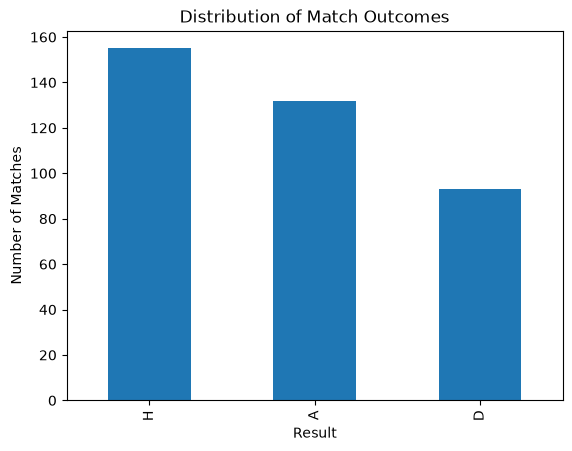

In [9]:
result_counts = df["FTR"].value_counts()

print(result_counts)

result_counts.plot(kind="bar")

plt.title("Distribution of Match Outcomes")
plt.xlabel("Result")
plt.ylabel("Number of Matches")

plt.show()

The distribution of match outcomes shows that home wins occur more frequently than draws and away wins.

## Goal Distributions

Goals scored by home and away teams provide insight into the attacking characteristics of Premier League matches.

In [10]:
print("Home Goals")
print(df["FTHG"].describe())

print("\nAway Goals")
print(df["FTAG"].describe())

Home Goals
count    380.000000
mean       1.513158
std        1.277917
min        0.000000
25%        1.000000
50%        1.000000
75%        2.000000
max        7.000000
Name: FTHG, dtype: float64

Away Goals
count    380.000000
mean       1.421053
std        1.189922
min        0.000000
25%        1.000000
50%        1.000000
75%        2.000000
max        6.000000
Name: FTAG, dtype: float64


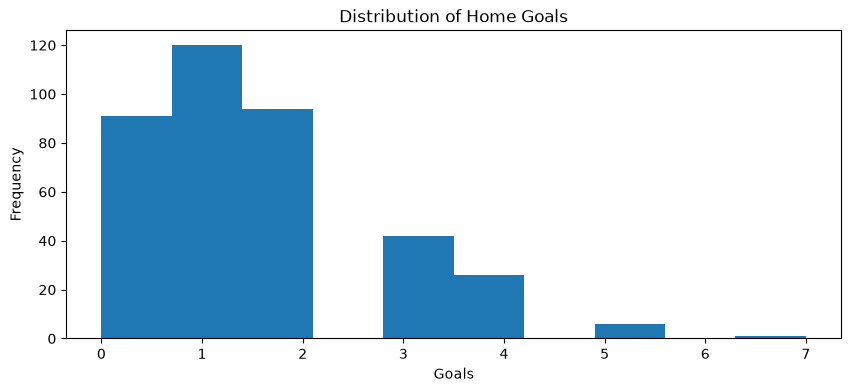

In [11]:
plt.figure(figsize=(10,4))

plt.hist(df["FTHG"], bins=10)

plt.title("Distribution of Home Goals")
plt.xlabel("Goals")
plt.ylabel("Frequency")

plt.show()

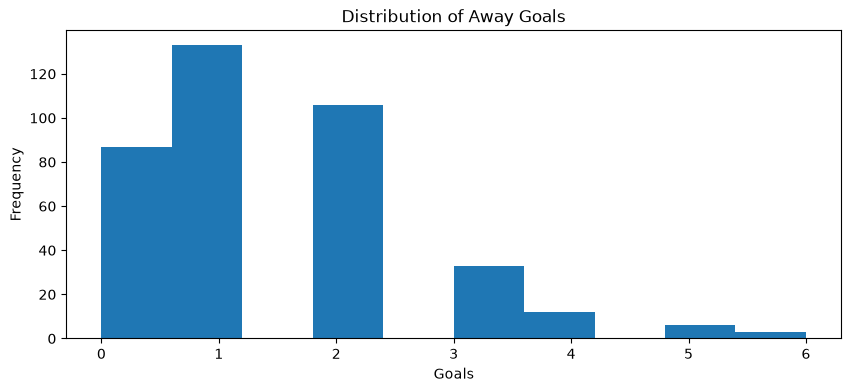

In [12]:
plt.figure(figsize=(10,4))

plt.hist(df["FTAG"], bins=10)

plt.title("Distribution of Away Goals")
plt.xlabel("Goals")
plt.ylabel("Frequency")

plt.show()

In [13]:
print("Average Home Goals:", df["FTHG"].mean())
print("Average Away Goals:", df["FTAG"].mean())

Average Home Goals: 1.513157894736842
Average Away Goals: 1.4210526315789473


Home teams score more goals on average than away teams.

The distributions are right-skewed, with most matches featuring between zero and three goals per team, while very high-scoring performances are relatively rare.

This observation is consistent with the home advantage previously identified in the match outcome analysis.

## Bookmaker Odds Analysis

Bookmaker odds reflect the market's expectations regarding match outcomes.

Lower odds correspond to outcomes that bookmakers consider more likely.

This analysis investigates the distributions of home win, draw and away win odds from Bet365.

In [14]:
bet365_cols = ["B365H", "B365D", "B365A"]
df[bet365_cols].describe()


,B365H,B365D,B365A
count,380.000000,380.000000,380.000000
mean,2.745368,4.327132,4.242289
std,1.733222,1.278749,3.169343
min,1.080000,3.100000,1.200000
25%,1.600000,3.600000,2.200000
50%,2.200000,3.900000,3.200000
75%,3.000000,4.500000,5.250000
max,11.000000,12.000000,23.000000


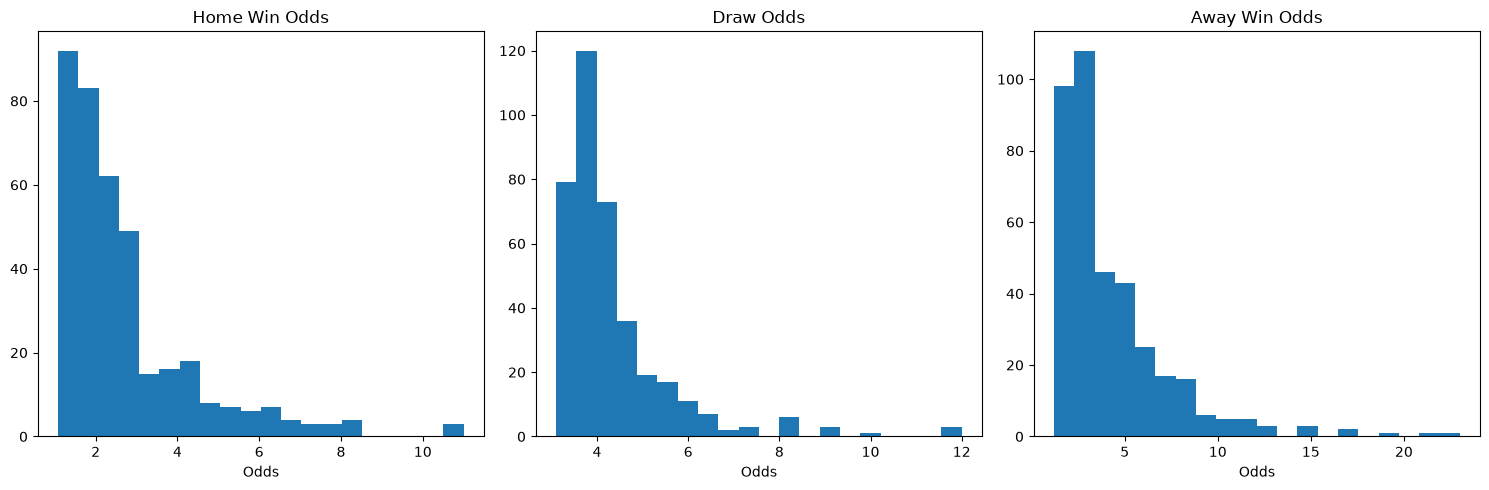

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))

axes[0].hist(df["B365H"], bins=20)
axes[0].set_title("Home Win Odds")
axes[0].set_xlabel("Odds")

axes[1].hist(df["B365D"], bins=20)
axes[1].set_title("Draw Odds")
axes[1].set_xlabel("Odds")

axes[2].hist(df["B365A"], bins=20)
axes[2].set_title("Away Win Odds")
axes[2].set_xlabel("Odds")

plt.tight_layout()
plt.show()

In [16]:
df.groupby("FTR")[["B365H", "B365D", "B365A"]].mean().round(2)

,B365H,B365D,B365A
FTR,,,
A,3.64,4.06,2.87
D,2.72,4.13,3.91
H,2.00,4.67,5.61


Comparing average odds across actual match outcomes provides an indication of whether bookmaker expectations align with realised results.

If bookmakers are effective, matches ending in home wins should generally have lower home-win odds than matches ending in draws or away wins.

In [17]:
def favourite(row):
    odds = {
        "H": row["B365H"],
        "D": row["B365D"],
        "A": row["B365A"]
    }
    return min(odds, key=odds.get)

df["Favourite"] = df.apply(favourite, axis=1)

/var/folders/cd/w3jr66f17t9cqg7l8tjxywc00000gn/T/ipykernel_57099/1119795174.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Favourite"] = df.apply(favourite, axis=1)


In [18]:
df["Favourite"].value_counts()

Favourite
H    246
A    134
Name: count, dtype: int64

In [19]:
favourite_accuracy = (
    df["Favourite"] == df["FTR"]
).mean()

print(f"Favourite Accuracy: {favourite_accuracy:.3f}")

Favourite Accuracy: 0.539


## Correlation Analysis

Correlation analysis helps identify relationships between key numerical variables in the dataset.


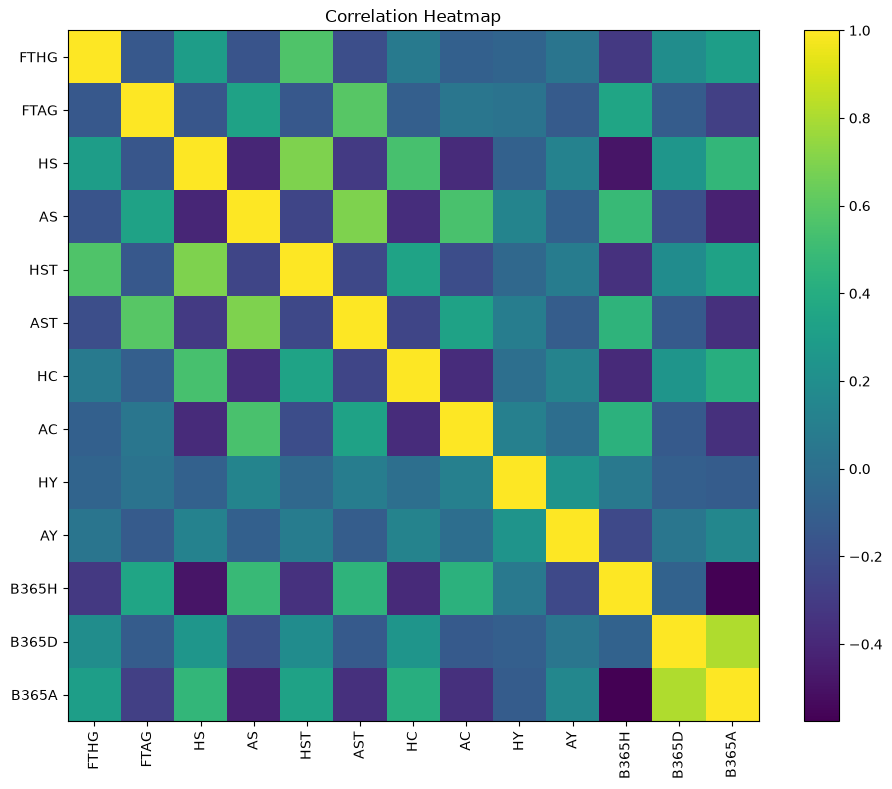

In [20]:
corr_cols = [
    "FTHG", "FTAG",
    "HS", "AS",
    "HST", "AST",
    "HC", "AC",
    "HY", "AY",
    "B365H", "B365D", "B365A"
]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10,8))

plt.imshow(corr_matrix)

plt.colorbar()

plt.xticks(
    range(len(corr_cols)),
    corr_cols,
    rotation=90
)

plt.yticks(
    range(len(corr_cols)),
    corr_cols
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

# 7. Feature Engineering

In [21]:
df["Prob_H"] = 1 / df["B365H"]
df["Prob_D"] = 1 / df["B365D"]
df["Prob_A"] = 1 / df["B365A"]

total = df["Prob_H"] + df["Prob_D"] + df["Prob_A"]

df["Prob_H"] /= total
df["Prob_D"] /= total
df["Prob_A"] /= total

/var/folders/cd/w3jr66f17t9cqg7l8tjxywc00000gn/T/ipykernel_57099/3382529114.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Prob_H"] = 1 / df["B365H"]
/var/folders/cd/w3jr66f17t9cqg7l8tjxywc00000gn/T/ipykernel_57099/3382529114.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Prob_D"] = 1 / df["B365D"]
/var/folders/cd/w3jr66f17t9cqg7l8tjxywc00000gn/T/ipykernel_57099/3382529114.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor p

In [22]:
df["HomeFav"] = (df["Favourite"] == "H").astype(int)
df["AwayFav"] = (df["Favourite"] == "A").astype(int)

/var/folders/cd/w3jr66f17t9cqg7l8tjxywc00000gn/T/ipykernel_57099/2118932171.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["HomeFav"] = (df["Favourite"] == "H").astype(int)
/var/folders/cd/w3jr66f17t9cqg7l8tjxywc00000gn/T/ipykernel_57099/2118932171.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["AwayFav"] = (df["Favourite"] == "A").astype(int)


In [23]:
def odds_gap(row):
    odds = sorted([row["B365H"], row["B365D"], row["B365A"]])
    return odds[1] - odds[0]

df["OddsGap"] = df.apply(odds_gap, axis=1)

/var/folders/cd/w3jr66f17t9cqg7l8tjxywc00000gn/T/ipykernel_57099/3790632128.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["OddsGap"] = df.apply(odds_gap, axis=1)


In [24]:
df["MaxProb"] = df[["Prob_H","Prob_D","Prob_A"]].max(axis=1)

/var/folders/cd/w3jr66f17t9cqg7l8tjxywc00000gn/T/ipykernel_57099/3667125150.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["MaxProb"] = df[["Prob_H","Prob_D","Prob_A"]].max(axis=1)


## Baseline Prediction Models

The first models are trained using only information derived from Bet365 betting odds.

This provides a bookmaker-based baseline against which football-specific features can later be compared.

A train-test split of 80%-20% is used to evaluate out-of-sample predictive performance.

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

features = [
    "Prob_H",
    "Prob_D",
    "Prob_A",
    "HomeFav",
    "AwayFav",
    "OddsGap",
    "MaxProb"
]

X = df[features]

y = df["FTR"]

encoder = LabelEncoder()
y = encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Logistic Regression

Logistic Regression is used as a simple baseline model.

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

log_model = LogisticRegression(
    max_iter=1000
)

log_model.fit(X_train, y_train)

log_preds = log_model.predict(X_test)

log_accuracy = accuracy_score(
    y_test,
    log_preds
)

print("Logistic Regression Accuracy:")
print(round(log_accuracy, 4))

Logistic Regression Accuracy:
0.4868


### Random Forest

In [27]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

rf_accuracy = accuracy_score(
    y_test,
    rf_preds
)

print("Random Forest Accuracy:")
print(round(rf_accuracy, 4))

Random Forest Accuracy:
0.4737


In [28]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        log_accuracy,
        rf_accuracy
    ]
})

results.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
0,Logistic Regression,0.486842
1,Random Forest,0.473684


In [29]:
fav_accuracy = (df["Favourite"] == df["FTR"]).mean()

print("Bookmaker Favourite Accuracy:")
print(round(fav_accuracy,4))

Bookmaker Favourite Accuracy:
0.5395


## Baseline Model Results

Three baseline approaches were evaluated using information derived solely from Bet365 betting odds:

1. Favourite Outcome Rule
2. Logistic Regression
3. Random Forest

The favourite outcome rule predicts whichever result (home win, draw, or away win) has the lowest bookmaker odds.

The machine learning models were trained using engineered features derived from the betting odds, including implied probabilities, favourite indicators, match competitiveness, and maximum implied probability.

In [30]:
results = pd.DataFrame({
    "Model": [
        "Favourite Rule",
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        fav_accuracy,
        log_accuracy,
        rf_accuracy
    ]
})

results.sort_values("Accuracy", ascending=False)

,Model,Accuracy
0,Favourite Rule,0.539474
1,Logistic Regression,0.486842
2,Random Forest,0.473684


The bookmaker favourite rule achieved the highest predictive accuracy among the baseline methods.

This suggests that much of the predictive information contained within the betting odds is already captured by the favourite outcome itself.

The machine learning models were unable to significantly improve upon this benchmark when only bookmaker-derived features were used.

This result is not unexpected, as bookmaker odds incorporate extensive information regarding team strength, injuries, historical performance, betting market activity and expert judgement.

The next stage of the project investigates whether football-specific features can provide additional predictive value beyond that already contained within the betting market.

## Football Feature Engineering

The previous models used only bookmaker-derived predictors. I now construct football-specific features using information that would have been available before each match.

The aim is to test whether recent team performance, league position, goal difference and home/away strength add predictive value beyond the Bet365 odds.

To avoid data leakage, each feature is calculated before updating a team's record with the current match result.


In [31]:

df = df.copy()


df["MatchDate"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")


if "Time" in df.columns:
    df["KickoffTime"] = df["Time"].fillna("00:00").astype(str)
    df["DateTime"] = pd.to_datetime(
        df["MatchDate"].dt.strftime("%Y-%m-%d") + " " + df["KickoffTime"],
        errors="coerce"
    )
else:
    df["DateTime"] = df["MatchDate"]

df["DateTime"] = df["DateTime"].fillna(df["MatchDate"])


df = df.sort_values(["DateTime", "HomeTeam", "AwayTeam"]).reset_index(drop=True)

In [32]:
teams = sorted(set(df["HomeTeam"]).union(set(df["AwayTeam"])))

# Create a dictionary to store each team's running statistics
team_stats = {}

for team in teams:
    team_stats[team] = {
        "played": 0,
        "points": 0,
        "gf": 0,
        "ga": 0,
        "wins": 0,
        "draws": 0,
        "losses": 0,
        "recent_points": [],
        "recent_gf": [],
        "recent_ga": [],
        "recent_gd": [],
        "recent_home_points": [],
        "recent_away_points": []
    }


def last_n_total(values, n=5):
    """
    Returns the total of the last n values.
    If the team has not played yet, return 0.
    """
    if len(values) == 0:
        return 0
    return sum(values[-n:])


def last_n_average(values, n=5):
    """
    Returns the average of the last n values.
    If the team has not played yet, return 0.
    """
    if len(values) == 0:
        return 0
    return sum(values[-n:]) / len(values[-n:])


def win_rate(stats):
    """
    Returns a team's win rate before the match.
    If the team has not played yet, return 0.
    """
    if stats["played"] == 0:
        return 0
    return stats["wins"] / stats["played"]


def get_league_positions(team_stats):
    """
    Calculates the league position before each match.

    Teams are ranked by:
    1. Points
    2. Goal difference
    3. Goals scored

    Tied teams receive the average of their tied positions.
    For example, if two teams are tied for 1st, both receive position 1.5.
    """
    table = []

    for team, stats in team_stats.items():
        table.append({
            "Team": team,
            "Points": stats["points"],
            "GD": stats["gf"] - stats["ga"],
            "GF": stats["gf"]
        })

    table = sorted(
        table,
        key=lambda x: (-x["Points"], -x["GD"], -x["GF"])
    )

    positions = {}
    i = 0

    while i < len(table):
        j = i

        # Find all teams tied on points, goal difference and goals for
        while (
            j + 1 < len(table)
            and table[j + 1]["Points"] == table[i]["Points"]
            and table[j + 1]["GD"] == table[i]["GD"]
            and table[j + 1]["GF"] == table[i]["GF"]
        ):
            j += 1

        # Average position for tied teams
        average_position = ((i + 1) + (j + 1)) / 2

        for k in range(i, j + 1):
            positions[table[k]["Team"]] = average_position

        i = j + 1

    return positions

In [33]:
feature_rows = []

# Group by DateTime so that simultaneous matches do not leak information into each other
for datetime_value, matches_at_time in df.groupby("DateTime", sort=True):

    # League positions before any matches at this kick-off time are played
    current_positions = get_league_positions(team_stats)

    # First create features for all matches at this kick-off time
    for idx, row in matches_at_time.iterrows():

        home_team = row["HomeTeam"]
        away_team = row["AwayTeam"]

        home_stats = team_stats[home_team]
        away_stats = team_stats[away_team]

        home_position = current_positions[home_team]
        away_position = current_positions[away_team]

        home_goal_diff_before = home_stats["gf"] - home_stats["ga"]
        away_goal_diff_before = away_stats["gf"] - away_stats["ga"]

        home_points_last5 = last_n_total(home_stats["recent_points"], 5)
        away_points_last5 = last_n_total(away_stats["recent_points"], 5)

        home_avg_points_last5 = last_n_average(home_stats["recent_points"], 5)
        away_avg_points_last5 = last_n_average(away_stats["recent_points"], 5)

        home_goals_scored_last5 = last_n_total(home_stats["recent_gf"], 5)
        away_goals_scored_last5 = last_n_total(away_stats["recent_gf"], 5)

        home_goals_conceded_last5 = last_n_total(home_stats["recent_ga"], 5)
        away_goals_conceded_last5 = last_n_total(away_stats["recent_ga"], 5)

        home_goal_diff_last5 = last_n_total(home_stats["recent_gd"], 5)
        away_goal_diff_last5 = last_n_total(away_stats["recent_gd"], 5)

        home_home_points_last5 = last_n_total(home_stats["recent_home_points"], 5)
        away_away_points_last5 = last_n_total(away_stats["recent_away_points"], 5)

        feature_rows.append({
            "row_index": idx,

            # Matches played before this fixture
            "HomeMatchesPlayedBefore": home_stats["played"],
            "AwayMatchesPlayedBefore": away_stats["played"],

            # League position before the match
            "HomeLeaguePosition": home_position,
            "AwayLeaguePosition": away_position,

            # Positive PositionDiff means the home team is higher in the table
            "PositionDiff": away_position - home_position,

            # Season performance before the match
            "HomeSeasonPointsBefore": home_stats["points"],
            "AwaySeasonPointsBefore": away_stats["points"],
            "SeasonPointsDiff": home_stats["points"] - away_stats["points"],

            "HomeSeasonGoalDiffBefore": home_goal_diff_before,
            "AwaySeasonGoalDiffBefore": away_goal_diff_before,
            "SeasonGoalDiffDiff": home_goal_diff_before - away_goal_diff_before,

            # Recent form: points in last 5 matches
            "HomePointsLast5": home_points_last5,
            "AwayPointsLast5": away_points_last5,
            "PointsLast5Diff": home_points_last5 - away_points_last5,

            # Average recent form
            "HomeAvgPointsLast5": home_avg_points_last5,
            "AwayAvgPointsLast5": away_avg_points_last5,
            "AvgPointsLast5Diff": home_avg_points_last5 - away_avg_points_last5,

            # Recent attacking form
            "HomeGoalsScoredLast5": home_goals_scored_last5,
            "AwayGoalsScoredLast5": away_goals_scored_last5,
            "GoalsScoredLast5Diff": home_goals_scored_last5 - away_goals_scored_last5,

            # Recent defensive form
            "HomeGoalsConcededLast5": home_goals_conceded_last5,
            "AwayGoalsConcededLast5": away_goals_conceded_last5,
            "GoalsConcededLast5Diff": home_goals_conceded_last5 - away_goals_conceded_last5,

            # Recent goal difference form
            "HomeGoalDiffLast5": home_goal_diff_last5,
            "AwayGoalDiffLast5": away_goal_diff_last5,
            "GoalDiffLast5Diff": home_goal_diff_last5 - away_goal_diff_last5,

            # Home/away-specific form
            "HomeHomePointsLast5": home_home_points_last5,
            "AwayAwayPointsLast5": away_away_points_last5,
            "HomeAwaySpecificFormDiff": home_home_points_last5 - away_away_points_last5,

            # Win-rate features before the match
            "HomeWinRateBefore": win_rate(home_stats),
            "AwayWinRateBefore": win_rate(away_stats),
            "WinRateDiff": win_rate(home_stats) - win_rate(away_stats)
        })

    # Then update team statistics after these matches have been played
    for idx, row in matches_at_time.iterrows():

        home_team = row["HomeTeam"]
        away_team = row["AwayTeam"]

        home_goals = row["FTHG"]
        away_goals = row["FTAG"]

        if home_goals > away_goals:
            home_points = 3
            away_points = 0
            home_result = "W"
            away_result = "L"
        elif home_goals < away_goals:
            home_points = 0
            away_points = 3
            home_result = "L"
            away_result = "W"
        else:
            home_points = 1
            away_points = 1
            home_result = "D"
            away_result = "D"

        # Update home team
        team_stats[home_team]["played"] += 1
        team_stats[home_team]["points"] += home_points
        team_stats[home_team]["gf"] += home_goals
        team_stats[home_team]["ga"] += away_goals

        team_stats[home_team]["recent_points"].append(home_points)
        team_stats[home_team]["recent_gf"].append(home_goals)
        team_stats[home_team]["recent_ga"].append(away_goals)
        team_stats[home_team]["recent_gd"].append(home_goals - away_goals)
        team_stats[home_team]["recent_home_points"].append(home_points)

        if home_result == "W":
            team_stats[home_team]["wins"] += 1
        elif home_result == "D":
            team_stats[home_team]["draws"] += 1
        else:
            team_stats[home_team]["losses"] += 1

        # Update away team
        team_stats[away_team]["played"] += 1
        team_stats[away_team]["points"] += away_points
        team_stats[away_team]["gf"] += away_goals
        team_stats[away_team]["ga"] += home_goals

        team_stats[away_team]["recent_points"].append(away_points)
        team_stats[away_team]["recent_gf"].append(away_goals)
        team_stats[away_team]["recent_ga"].append(home_goals)
        team_stats[away_team]["recent_gd"].append(away_goals - home_goals)
        team_stats[away_team]["recent_away_points"].append(away_points)

        if away_result == "W":
            team_stats[away_team]["wins"] += 1
        elif away_result == "D":
            team_stats[away_team]["draws"] += 1
        else:
            team_stats[away_team]["losses"] += 1

In [34]:
football_features_df = (
    pd.DataFrame(feature_rows)
    .set_index("row_index")
    .sort_index()
)

df = pd.concat([df, football_features_df], axis=1)

df.head()

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,GoalsConcededLast5Diff,HomeGoalDiffLast5,AwayGoalDiffLast5,GoalDiffLast5Diff,HomeHomePointsLast5,AwayAwayPointsLast5,HomeAwaySpecificFormDiff,HomeWinRateBefore,AwayWinRateBefore,WinRateDiff
0,E0,16/08/2024,20:00,Man United,Fulham,1,0,H,0,0,...,0,0,0,0,0,0,0,0.0,0.0,0.0
1,E0,17/08/2024,12:30,Ipswich,Liverpool,0,2,A,0,0,...,0,0,0,0,0,0,0,0.0,0.0,0.0
2,E0,17/08/2024,15:00,Arsenal,Wolves,2,0,H,1,0,...,0,0,0,0,0,0,0,0.0,0.0,0.0
3,E0,17/08/2024,15:00,Everton,Brighton,0,3,A,0,1,...,0,0,0,0,0,0,0,0.0,0.0,0.0
4,E0,17/08/2024,15:00,Newcastle,Southampton,1,0,H,1,0,...,0,0,0,0,0,0,0,0.0,0.0,0.0


In [35]:
football_features = [
    "HomeMatchesPlayedBefore",
    "AwayMatchesPlayedBefore",

    "HomeLeaguePosition",
    "AwayLeaguePosition",
    "PositionDiff",

    "HomeSeasonPointsBefore",
    "AwaySeasonPointsBefore",
    "SeasonPointsDiff",

    "HomeSeasonGoalDiffBefore",
    "AwaySeasonGoalDiffBefore",
    "SeasonGoalDiffDiff",

    "HomePointsLast5",
    "AwayPointsLast5",
    "PointsLast5Diff",

    "HomeAvgPointsLast5",
    "AwayAvgPointsLast5",
    "AvgPointsLast5Diff",

    "HomeGoalsScoredLast5",
    "AwayGoalsScoredLast5",
    "GoalsScoredLast5Diff",

    "HomeGoalsConcededLast5",
    "AwayGoalsConcededLast5",
    "GoalsConcededLast5Diff",

    "HomeGoalDiffLast5",
    "AwayGoalDiffLast5",
    "GoalDiffLast5Diff",

    "HomeHomePointsLast5",
    "AwayAwayPointsLast5",
    "HomeAwaySpecificFormDiff",

    "HomeWinRateBefore",
    "AwayWinRateBefore",
    "WinRateDiff"
]

In [36]:
df[
    [
        "Date",
        "HomeTeam",
        "AwayTeam",
        "FTR",
        "HomeLeaguePosition",
        "AwayLeaguePosition",
        "PositionDiff",
        "HomePointsLast5",
        "AwayPointsLast5",
        "PointsLast5Diff",
        "HomeGoalsScoredLast5",
        "AwayGoalsScoredLast5",
        "HomeGoalsConcededLast5",
        "AwayGoalsConcededLast5",
        "HomeGoalDiffLast5",
        "AwayGoalDiffLast5"
    ]
].head(15)

,Date,HomeTeam,AwayTeam,FTR,HomeLeaguePosition,AwayLeaguePosition,PositionDiff,HomePointsLast5,AwayPointsLast5,PointsLast5Diff,HomeGoalsScoredLast5,AwayGoalsScoredLast5,HomeGoalsConcededLast5,AwayGoalsConcededLast5,HomeGoalDiffLast5,AwayGoalDiffLast5
0,16/08/2024,Man United,Fulham,H,10.5,10.5,0.0,0,0,0,0,0,0,0,0,0
1,17/08/2024,Ipswich,Liverpool,A,10.5,10.5,0.0,0,0,0,0,0,0,0,0,0
2,17/08/2024,Arsenal,Wolves,H,10.5,10.5,0.0,0,0,0,0,0,0,0,0,0
3,17/08/2024,Everton,Brighton,A,10.5,10.5,0.0,0,0,0,0,0,0,0,0,0
4,17/08/2024,Newcastle,Southampton,H,10.5,10.5,0.0,0,0,0,0,0,0,0,0,0
5,17/08/2024,Nott'm Forest,Bournemouth,D,10.5,10.5,0.0,0,0,0,0,0,0,0,0,0
6,17/08/2024,West Ham,Aston Villa,A,11.5,11.5,0.0,0,0,0,0,0,0,0,0,0
7,18/08/2024,Brentford,Crystal Palace,H,11.5,11.5,0.0,0,0,0,0,0,0,0,0,0
8,18/08/2024,Chelsea,Man City,A,11.5,11.5,0.0,0,0,0,0,0,0,0,0,0
9,19/08/2024,Leicester,Tottenham,D,11.5,11.5,0.0,0,0,0,0,0,0,0,0,0


## Football Feature Engineering

Football-specific features were created to capture team strength and recent performance. These include league position, recent form, goals scored and conceded, goal difference, and win rate.

All features were generated chronologically using only information available before each match, ensuring that no future information was leaked into the model.

## Football-Only Prediction Models

The previous models used Bet365-derived features as predictors. I now train models using only football-specific features.

These features include league position, recent form, season points, goal difference, recent goals scored and conceded, and win rate. This allows us to test whether football performance variables alone can predict match outcomes.

The same modelling approach is used as before: Logistic Regression and Random Forest classification. This keeps the comparison with the Bet365-only models fair.

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import pandas as pd

# Use only football-specific features
X_football = df[football_features]
y = df["FTR"]

# Remove rows with missing football features
football_model_df = pd.concat([X_football, y], axis=1).dropna()

X_football = football_model_df[football_features]
y = football_model_df["FTR"]

# Encode target variable: A, D, H -> numeric labels
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# Same split style as previous Bet365 model
X_train_football, X_test_football, y_train_football, y_test_football = train_test_split(
    X_football,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training matches:", X_train_football.shape[0])
print("Testing matches:", X_test_football.shape[0])

Training matches: 304
Testing matches: 76


In [38]:
# Logistic Regression model

football_log_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

football_log_model.fit(X_train_football, y_train_football)

football_log_preds = football_log_model.predict(X_test_football)

football_log_accuracy = accuracy_score(
    y_test_football,
    football_log_preds
)

football_log_f1 = f1_score(
    y_test_football,
    football_log_preds,
    average="macro"
)

print("Football-Only Logistic Regression Accuracy:")
print(round(football_log_accuracy, 4))

print("Football-Only Logistic Regression Macro F1:")
print(round(football_log_f1, 4))

Football-Only Logistic Regression Accuracy:
0.4737
Football-Only Logistic Regression Macro F1:
0.396


In [39]:
football_rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    random_state=42
)

football_rf_model.fit(X_train_football, y_train_football)

football_rf_preds = football_rf_model.predict(X_test_football)

football_rf_accuracy = accuracy_score(
    y_test_football,
    football_rf_preds
)

football_rf_f1 = f1_score(
    y_test_football,
    football_rf_preds,
    average="macro"
)

print("Football-Only Random Forest Accuracy:")
print(round(football_rf_accuracy, 4))

print("Football-Only Random Forest Macro F1:")
print(round(football_rf_f1, 4))

Football-Only Random Forest Accuracy:
0.4211
Football-Only Random Forest Macro F1:
0.3138


In [40]:
football_only_results = pd.DataFrame({
    "Feature Set": [
        "Football Features Only",
        "Football Features Only"
    ],
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        football_log_accuracy,
        football_rf_accuracy
    ],
    "Macro F1": [
        football_log_f1,
        football_rf_f1
    ]
})

football_only_results

,Feature Set,Model,Accuracy,Macro F1
0,Football Features Only,Logistic Regression,0.473684,0.396049
1,Football Features Only,Random Forest,0.421053,0.313820


## Football-Only Model Comparison

The football-only models performed worse than the Bet365-only models. The football-only Logistic Regression model achieved an accuracy of 0.474, compared with 0.487 for the Bet365-only Logistic Regression model. The football-only Random Forest model achieved an accuracy of 0.421, compared with 0.474 for the Bet365-only Random Forest model.

The strongest previous baseline was still the Bet365 favourite rule, which achieved an accuracy of 0.5395. This suggests that bookmaker odds contain stronger predictive information than the engineered football features alone.

However, the football-only Logistic Regression model still performed reasonably close to the Bet365 machine learning models, suggesting that the football features do contain some useful signal. The next step is therefore to combine Bet365 features with football-specific features to test whether they add extra predictive value beyond the betting market.

In [41]:
# Bet365 features created earlier in the project
bet365_features = [
    "Prob_H",
    "Prob_D",
    "Prob_A",
    "HomeFav",
    "AwayFav",
    "OddsGap",
    "MaxProb"
]

# Combined feature set
combined_features = bet365_features + football_features

# Check all combined features exist
missing_features = [col for col in combined_features if col not in df.columns]

if len(missing_features) > 0:
    print("Missing features:", missing_features)
else:
    print("All combined features are present.")

All combined features are present.


In [42]:
# Create combined modelling dataset
X_combined = df[combined_features]
y = df["FTR"]

# Remove rows with missing values
combined_model_df = pd.concat([X_combined, y], axis=1).dropna()

X_combined = combined_model_df[combined_features]
y = combined_model_df["FTR"]

# Encode target variable
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# Use the same train-test split style as before
X_train_combined, X_test_combined, y_train_combined, y_test_combined = train_test_split(
    X_combined,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training matches:", X_train_combined.shape[0])
print("Testing matches:", X_test_combined.shape[0])

Training matches: 304
Testing matches: 76


In [43]:
# Combined Logistic Regression model

combined_log_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

combined_log_model.fit(X_train_combined, y_train_combined)

combined_log_preds = combined_log_model.predict(X_test_combined)

combined_log_accuracy = accuracy_score(
    y_test_combined,
    combined_log_preds
)

combined_log_f1 = f1_score(
    y_test_combined,
    combined_log_preds,
    average="macro"
)

print("Combined Logistic Regression Accuracy:")
print(round(combined_log_accuracy, 4))

print("Combined Logistic Regression Macro F1:")
print(round(combined_log_f1, 4))

Combined Logistic Regression Accuracy:
0.4737
Combined Logistic Regression Macro F1:
0.41


In [44]:
# Combined Random Forest model

combined_rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    random_state=42
)

combined_rf_model.fit(X_train_combined, y_train_combined)

combined_rf_preds = combined_rf_model.predict(X_test_combined)

combined_rf_accuracy = accuracy_score(
    y_test_combined,
    combined_rf_preds
)

combined_rf_f1 = f1_score(
    y_test_combined,
    combined_rf_preds,
    average="macro"
)

print("Combined Random Forest Accuracy:")
print(round(combined_rf_accuracy, 4))

print("Combined Random Forest Macro F1:")
print(round(combined_rf_f1, 4))

Combined Random Forest Accuracy:
0.4605
Combined Random Forest Macro F1:
0.3636


In [45]:
combined_results = pd.DataFrame({
    "Feature Set": [
        "Bet365 + Football Features",
        "Bet365 + Football Features"
    ],
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        combined_log_accuracy,
        combined_rf_accuracy
    ],
    "Macro F1": [
        combined_log_f1,
        combined_rf_f1
    ]
})

combined_results

,Feature Set,Model,Accuracy,Macro F1
0,Bet365 + Football Features,Logistic Regression,0.473684,0.410016
1,Bet365 + Football Features,Random Forest,0.460526,0.363554


## Final Conclusion

This project investigated whether Premier League match outcomes could be predicted using bookmaker odds, engineered football performance features, and a combination of both.

The strongest overall baseline was the simple Bet365 favourite rule, which achieved an accuracy of 0.5395. This means that simply predicting the outcome with the lowest Bet365 odds performed better than the machine learning models trained in this project.

The Bet365-only machine learning models achieved accuracies of approximately 0.487 for Logistic Regression and 0.474 for Random Forest. The football-only models achieved accuracies of approximately 0.474 for Logistic Regression and 0.421 for Random Forest. This suggests that the engineered football features contained some predictive signal, particularly for the Logistic Regression model, but were weaker than the betting market information overall.

The combined models did not improve predictive accuracy beyond the Bet365-only models. The combined Logistic Regression model achieved an accuracy of 0.474, while the combined Random Forest model achieved an accuracy of 0.461. Therefore, adding football-specific features to the Bet365 predictors did not produce a clear improvement in predictive performance.

This suggests that Bet365 odds already capture much of the relevant information contained in football performance variables such as recent form, league position, goal difference and win rate. This is reasonable because bookmaker odds are likely to incorporate a wide range of information, including team strength, home advantage, injuries, recent performances and market expectations.

One interesting point is that the combined Logistic Regression model achieved a slightly higher Macro F1 score than the football-only Logistic Regression model. This suggests that combining features may have helped the model balance predictions across home wins, draws and away wins slightly better, even though it did not improve overall accuracy.

Overall, the project shows that bookmaker odds are a very strong benchmark for football match prediction. The engineered football features were useful but did not add enough independent information to outperform the betting market. A natural extension would be to use multiple seasons of data, include richer features such as injuries, expected goals, team ratings and squad strength, and test whether more advanced models can improve performance.

The key conclusion is that the betting market remained more predictive than the engineered football features, and the combined model did not provide evidence of additional predictive value beyond Bet365 odds.